## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


## Import Appropriate Packages

In [1]:
import spacy 
spacy.cli.download("en_core_web_sm")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# make a path for the outputs
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis.gensim_models
from gensim.corpora.dictionary import Dictionary

## Load Data

In [7]:
nlp = spacy.load("en_core_web_sm")

In [8]:
sou = pd.read_csv("data/SOTU.csv")

## LDA

In [9]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [10]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

In [11]:
# Build dictionary
dictionary = Dictionary(processed_docs) 
dictionary.filter_extremes(no_below=5, no_above=0.5) # Filter rare/common words 
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [12]:
# train LDA model with 18 topics
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=18, random_state=42, passes=10)

In [16]:
# print the top 10 words for each topic
print("\n--- LDA Topics ---") 
for idx, topic in lda_model.print_topics(-1): 
    print(f"Topic: {idx} \nWords: {topic}\n")


--- LDA Topics ---
Topic: 0 
Words: 0.008*"canal" + 0.005*"tariff" + 0.004*"panama" + 0.004*"statute" + 0.004*"company" + 0.004*"method" + 0.004*"convention" + 0.003*"board" + 0.003*"cent" + 0.003*"china"

Topic: 1 
Words: 0.003*"mexico" + 0.001*"texas" + 0.001*"mexican" + 0.001*"convention" + 0.001*"americans" + 0.001*"minister" + 0.001*"program" + 0.001*"article" + 0.001*"cent" + 0.001*"loan"

Topic: 2 
Words: 0.006*"method" + 0.005*"board" + 0.005*"agricultural" + 0.005*"farmer" + 0.005*"cent" + 0.004*"farm" + 0.004*"project" + 0.004*"veteran" + 0.004*"depression" + 0.004*"committee"

Topic: 3 
Words: 0.004*"cent" + 0.004*"gold" + 0.004*"silver" + 0.003*"indian" + 0.003*"june" + 0.003*"bond" + 0.003*"method" + 0.003*"island" + 0.002*"conference" + 0.002*"tariff"

Topic: 4 
Words: 0.019*"spain" + 0.009*"article" + 0.007*"minister" + 0.006*"likewise" + 0.005*"manufacture" + 0.005*"port" + 0.005*"tribe" + 0.005*"intercourse" + 0.004*"presume" + 0.004*"colony"

Topic: 5 
Words: 0.009*"

In [17]:
# print the topic distribution for the first speech
first_speech_topics = lda_model.get_document_topics(corpus[0])
print(first_speech_topics)

[(7, 0.99942523)]


The most prominent topic was topic 7 with a percentage of 99.94%. This topic contains words related to national identity/politics.

In [19]:
# make an interactive visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_intertopic_map = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.save_html(lda_intertopic_map, str(OUTPUT_DIR / "lda_intertopic_distance_map.html"))
lda_intertopic_map

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
16     0.124684 -0.016058       1        1  23.652614
3      0.047043  0.069631       2        1  22.188441
7     -0.249568 -0.032435       3        1  16.493435
15    -0.148444  0.093409       4        1  12.986374
0      0.042368  0.115060       5        1   6.480464
12     0.140061 -0.005773       6        1   6.076664
2     -0.028744  0.157597       7        1   3.946231
14     0.115200  0.048899       8        1   2.810588
10     0.072309  0.026057       9        1   2.145900
4      0.168740 -0.086130      10        1   1.301744
6     -0.162808 -0.128171      11        1   0.610862
5     -0.012308  0.061678      12        1   0.486794
9     -0.084382  0.041350      13        1   0.414846
17     0.051993 -0.138049      14        1   0.284721
13     0.022478 -0.077904      15        1   0.108571
1     -0.025788 -0.039226      16        1   0.003917
8     -0.027274 -0.044925      17        1   0.003917
11    -0.045561 -0.045010      18        1   0.003917, topic_info=           Term         Freq        Total Category  logprob  loglift
31    americans   983.000000   983.000000  Default  30.0000  30.0000
509     program  1305.000000  1305.000000  Default  29.0000  29.0000
665     tonight   654.000000   654.000000  Default  28.0000  28.0000
976      mexico   820.000000   820.000000  Default  27.0000  27.0000
656       thank   374.000000   374.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
1653       area     0.006954   441.132079  Topic18  -7.5829  -0.9101
737      worker     0.006925   457.663616  Topic18  -7.5871  -0.9510
3016    surplus     0.006855   448.043797  Topic18  -7.5973  -0.9400
407    minister     0.006909   556.381164  Topic18  -7.5894  -1.1487
2169     island     0.006898   582.759620  Topic18  -7.5910  -1.1966

[1340 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
5548      4  0.188494   -the
5548      6  0.188494   -the
5548      8  0.376987   -the
5548     13  0.188494   -the
7117      1  0.908890   1794
...     ...       ...    ...
742       9  0.026307  young
742      11  0.016442  young
742      12  0.006577  young
742      13  0.003288  young
6556      2  0.910513  yukon

[5421 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[17, 4, 8, 16, 1, 13, 3, 15, 11, 5, 7, 6, 10, 18, 14, 2, 9, 12])

## BERTopic

In [20]:
docs = sou['Text'].to_list()

In [21]:
# train the model - this takes about 30 seconds
# remove stop words from the topics
vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(min_topic_size=3)

topics, probs = topic_model.fit_transform(docs)

topic_model.update_topics(docs, vectorizer_model=vectorizer_model)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [22]:
# output the top 10 words for each topic
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,67,-1_government_states_united_congress,"[government, states, united, congress, people,...",[\nTo the Congress of the United States:\nYour...
1,0,25,0_world_people_years_new,"[world, people, years, new, american, america,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,15,1_states_government_united_congress,"[states, government, united, congress, public,...",[\nFellow-Citizens of the Senate and House of ...
3,2,14,2_government_states_united_year,"[government, states, united, year, law, congre...",[\nTo the Senate and House of Representatives:...
4,3,11,3_world_nations_soviet_peace,"[world, nations, soviet, peace, economic, free...","[\nMr. President, Mr. Speaker, Members of the ..."
5,4,11,4_new_america_americans_american,"[new, america, americans, american, people, to...","[\nMadam Speaker, Mr. Vice President, Members ..."
6,5,11,5_america_american_americans_tonight,"[america, american, americans, tonight, people...","[\nMr. Speaker, Mr. Vice President, Members of..."
7,6,11,6_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
8,7,10,7_states_government_united_congress,"[states, government, united, congress, country...",[\nFellow-Citizens of the Senate and of the Ho...
9,8,8,8_states_public_government_united,"[states, public, government, united, state, co...",[\nFellow-Citizens of the Senate and House of ...


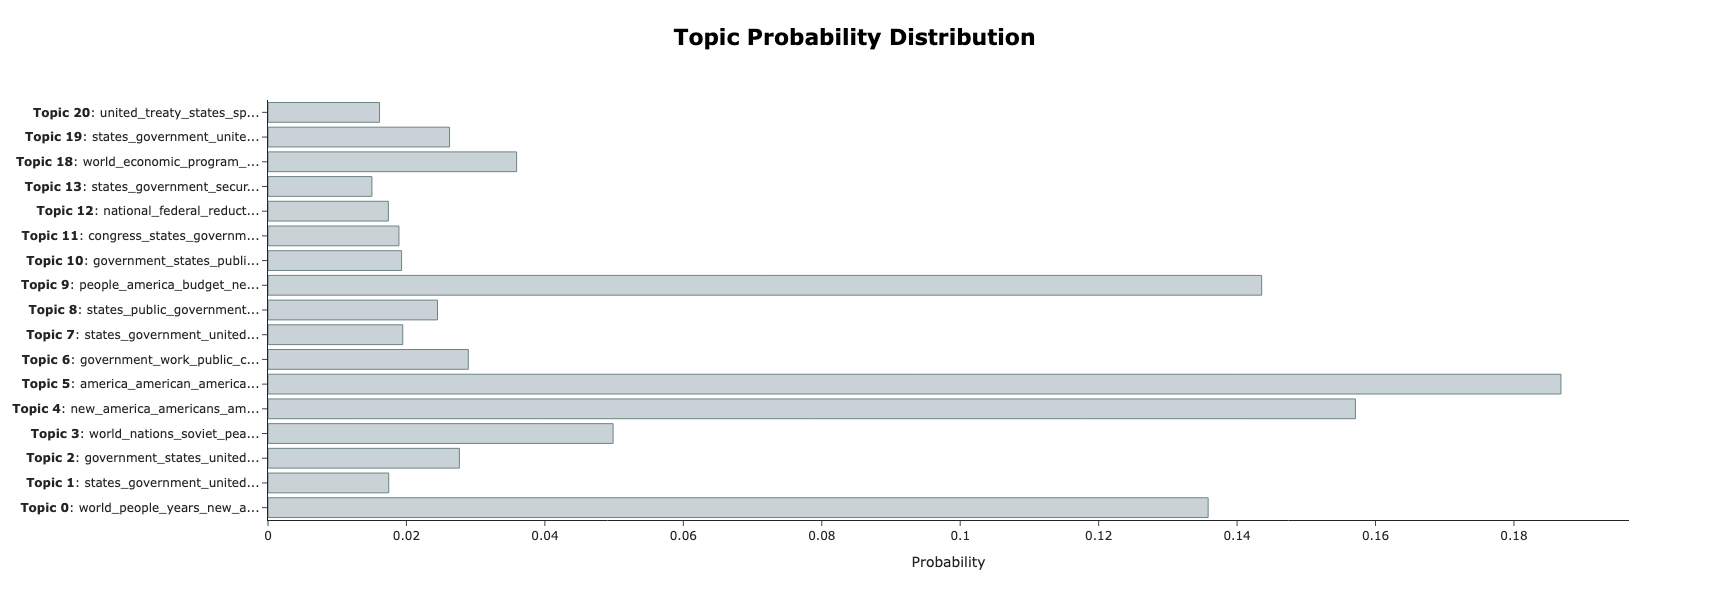

In [23]:
# output the topic distribution for the first speech
topic_dist = topic_model.approximate_distribution(docs)
topic_dist_fig = topic_model.visualize_distribution(topic_dist[0][0])

topic_dist_fig.write_html(str(OUTPUT_DIR / "topic_visualization.html"))
topic_dist_fig.show()

The most prominent topics seem to be strongly centered around America.

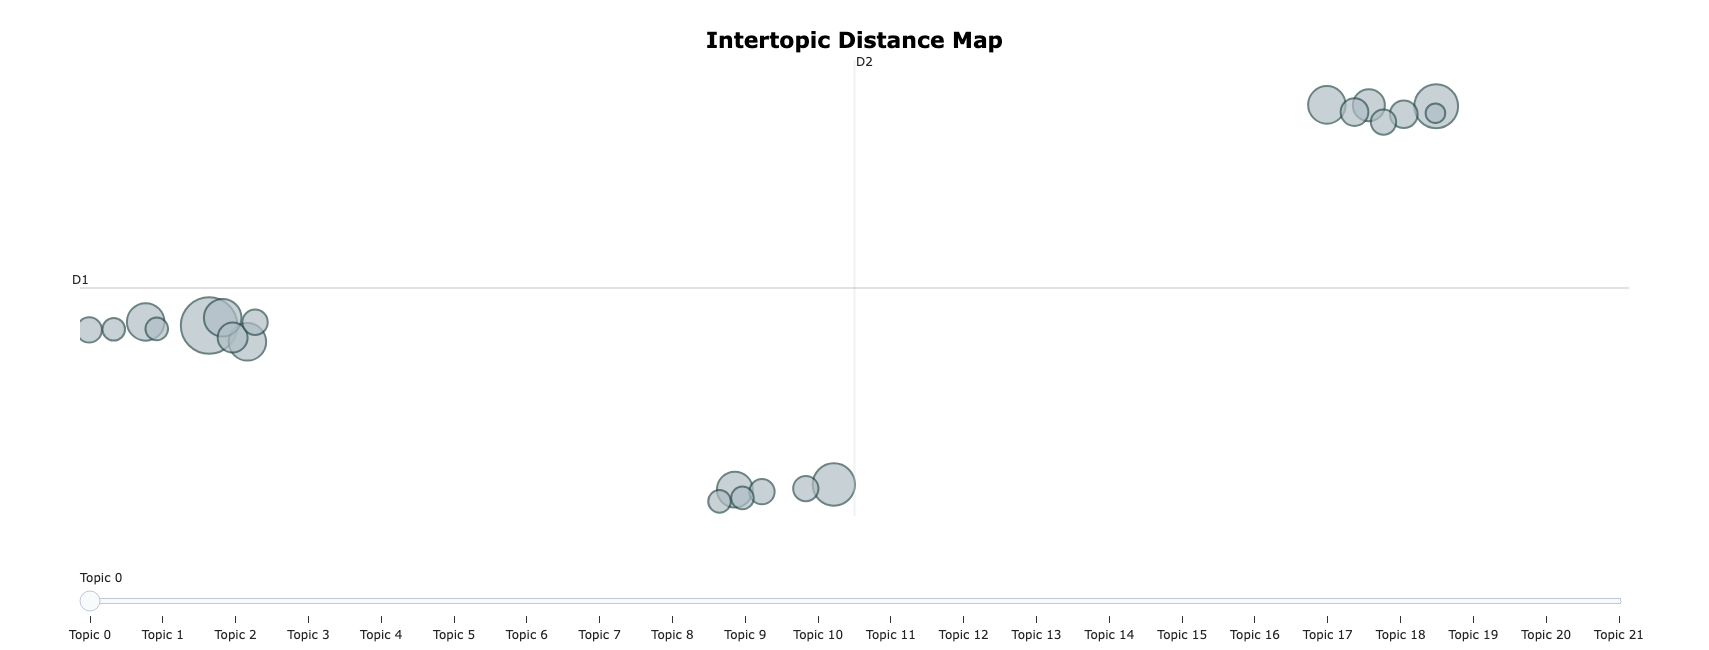

In [24]:
# run this cell to visualize the topics
intertopic_dist_fig = topic_model.visualize_topics()
intertopic_dist_fig.write_html(str(OUTPUT_DIR / "intertopic_distance_map.html"))
intertopic_dist_fig.show()